# SML

**Multiple Linear Regression - Bike Sales**

In [135]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import seaborn as sns

In [136]:
df = pd.read_csv(r"C:\Users\Yug\Downloads\day.csv")
df_eda = df.copy()  
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [137]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    object 
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  cnt         730 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.4+ KB


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,365.500000,2.498630,0.500000,6.526027,0.028767,2.997260,0.683562,1.394521,20.319259,23.726322,62.765175,12.763620,849.249315,3658.757534,4508.006849
std,210.877136,1.110184,0.500343,3.450215,0.167266,2.006161,0.465405,0.544807,7.506729,8.150308,14.237589,5.195841,686.479875,1559.758728,1936.011647
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.424346,3.953480,0.000000,1.500244,2.000000,20.000000,22.000000
25%,183.250000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,13.811885,16.889713,52.000000,9.041650,316.250000,2502.250000,3169.750000
50%,365.500000,3.000000,0.500000,7.000000,0.000000,3.000000,1.000000,1.000000,20.465826,24.368225,62.625000,12.125325,717.000000,3664.500000,4548.500000
75%,547.750000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,26.880615,30.445775,72.989575,15.625589,1096.500000,4783.250000,5966.000000
max,730.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,35.328347,42.044800,97.250000,34.000021,3410.000000,6946.000000,8714.000000


In [138]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [139]:
df.duplicated().sum()
# Remove duplicates if any
df.drop_duplicates(inplace=True)
df.shape

(730, 16)

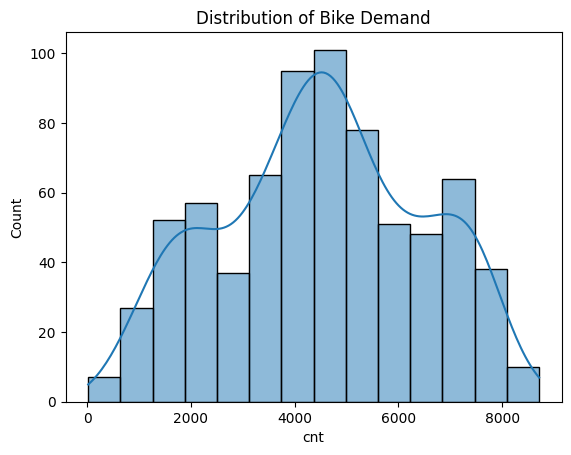

In [140]:
sns.histplot(df['cnt'], kde=True)
plt.title("Distribution of Bike Demand")
plt.show()

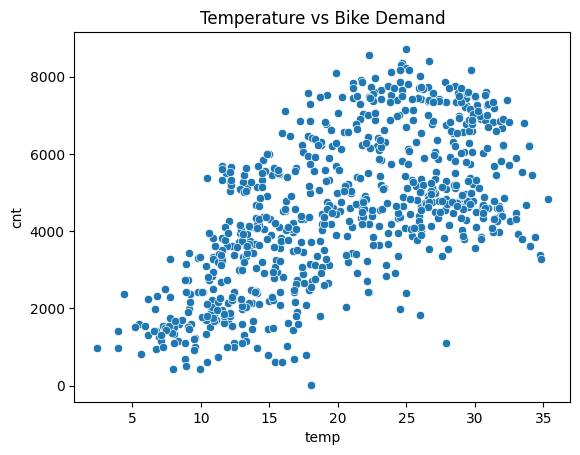

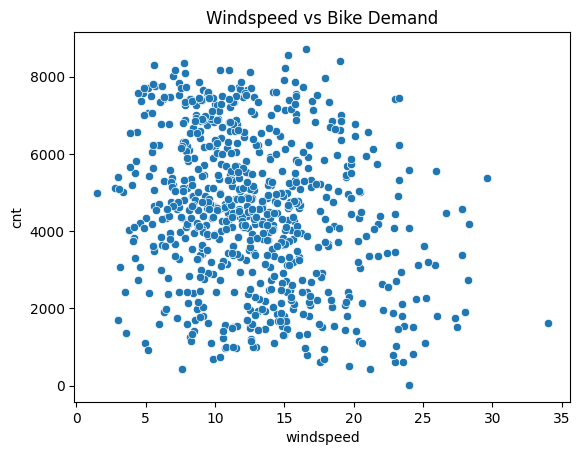

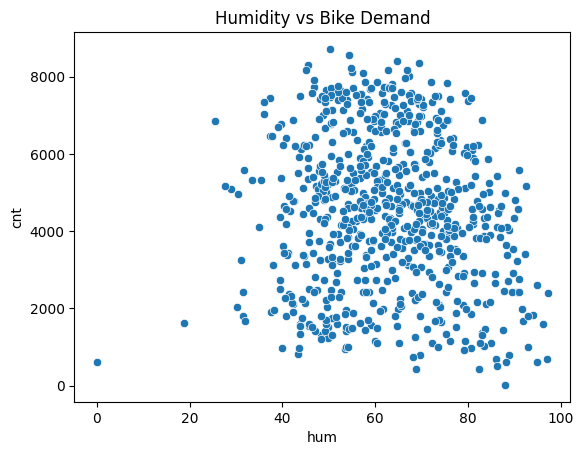

In [141]:
sns.scatterplot(x='temp', y='cnt', data=df_eda)
plt.title("Temperature vs Bike Demand")
plt.show()

sns.scatterplot(x='windspeed', y='cnt', data=df_eda)
plt.title("Windspeed vs Bike Demand")
plt.show()

sns.scatterplot(x='hum', y='cnt', data=df_eda)
plt.title("Humidity vs Bike Demand")
plt.show()


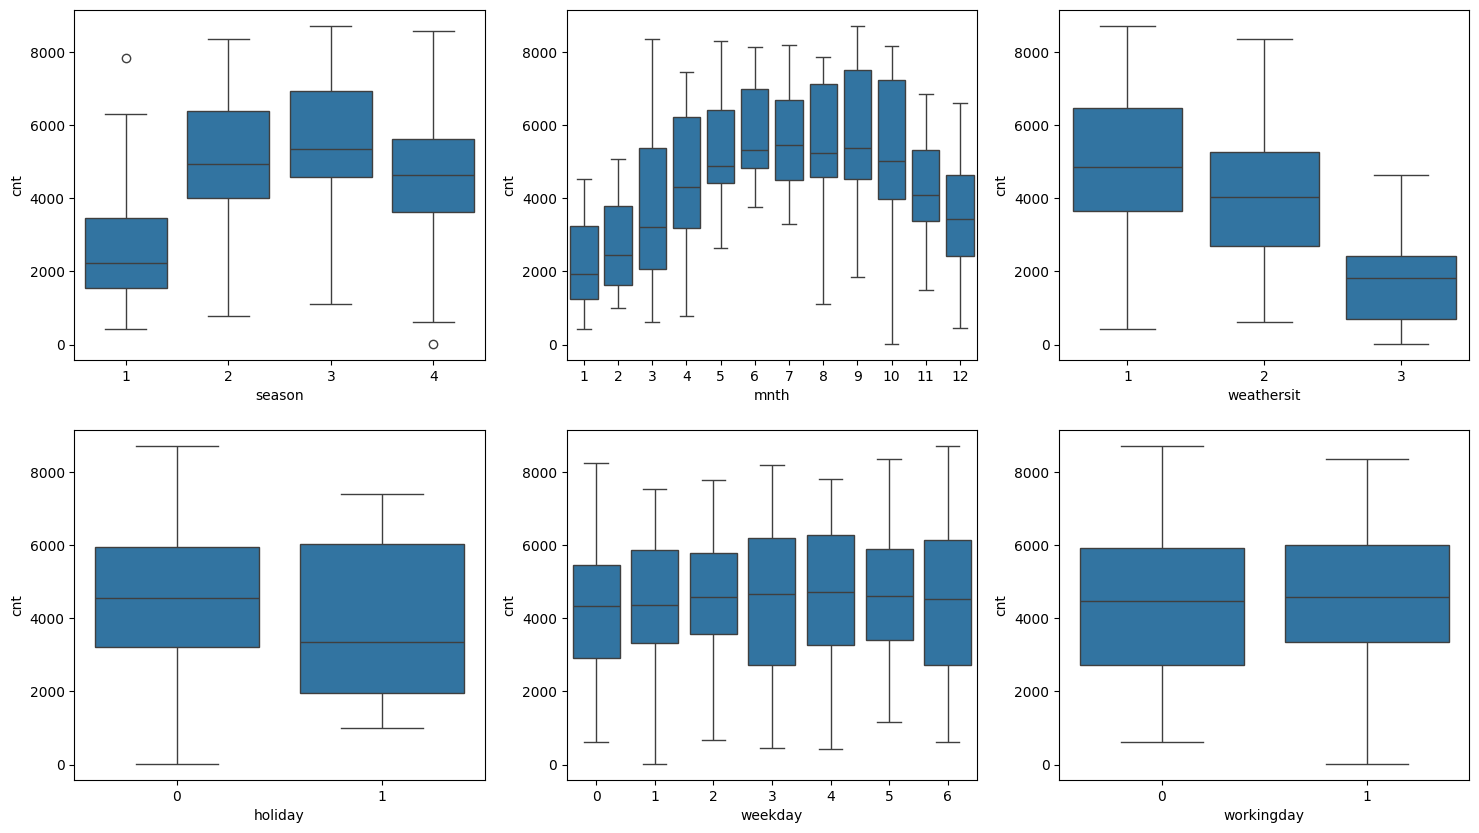

In [142]:
plt.figure(figsize=(18,10))

plt.subplot(2,3,1)
sns.boxplot(x='season', y='cnt', data=df_eda)

plt.subplot(2,3,2)
sns.boxplot(x='mnth', y='cnt', data=df_eda)

plt.subplot(2,3,3)
sns.boxplot(x='weathersit', y='cnt', data=df_eda)

plt.subplot(2,3,4)
sns.boxplot(x='holiday', y='cnt', data=df_eda)

plt.subplot(2,3,5)
sns.boxplot(x='weekday', y='cnt', data=df_eda)

plt.subplot(2,3,6)
sns.boxplot(x='workingday', y='cnt', data=df_eda)

plt.show()


In [143]:
# Drop unwanted columns
df.drop(['instant', 'dteday', 'casual', 'registered'], axis=1, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      730 non-null    int64  
 1   yr          730 non-null    int64  
 2   mnth        730 non-null    int64  
 3   holiday     730 non-null    int64  
 4   weekday     730 non-null    int64  
 5   workingday  730 non-null    int64  
 6   weathersit  730 non-null    int64  
 7   temp        730 non-null    float64
 8   atemp       730 non-null    float64
 9   hum         730 non-null    float64
 10  windspeed   730 non-null    float64
 11  cnt         730 non-null    int64  
dtypes: float64(4), int64(8)
memory usage: 68.6 KB


In [144]:
# Converting to categorical column
cat_cols = ['season', 'mnth', 'weekday', 'weathersit']
for col in cat_cols:
    df[col] = df[col].astype('category')

In [145]:
# One-Hot encoding
df = pd.get_dummies(df, drop_first=True)
df.head()

,yr,holiday,workingday,temp,atemp,hum,windspeed,cnt,season_2,season_3,...,mnth_11,mnth_12,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weathersit_2,weathersit_3
0,0,0,0,14.110847,18.18125,80.5833,10.749882,985,False,False,...,False,False,False,False,False,False,False,True,True,False
1,0,0,0,14.902598,17.68695,69.6087,16.652113,801,False,False,...,False,False,False,False,False,False,False,False,True,False
2,0,0,1,8.050924,9.47025,43.7273,16.636703,1349,False,False,...,False,False,True,False,False,False,False,False,False,False
3,0,0,1,8.200000,10.60610,59.0435,10.739832,1562,False,False,...,False,False,False,True,False,False,False,False,False,False
4,0,0,1,9.305237,11.46350,43.6957,12.522300,1600,False,False,...,False,False,False,False,True,False,False,False,False,False


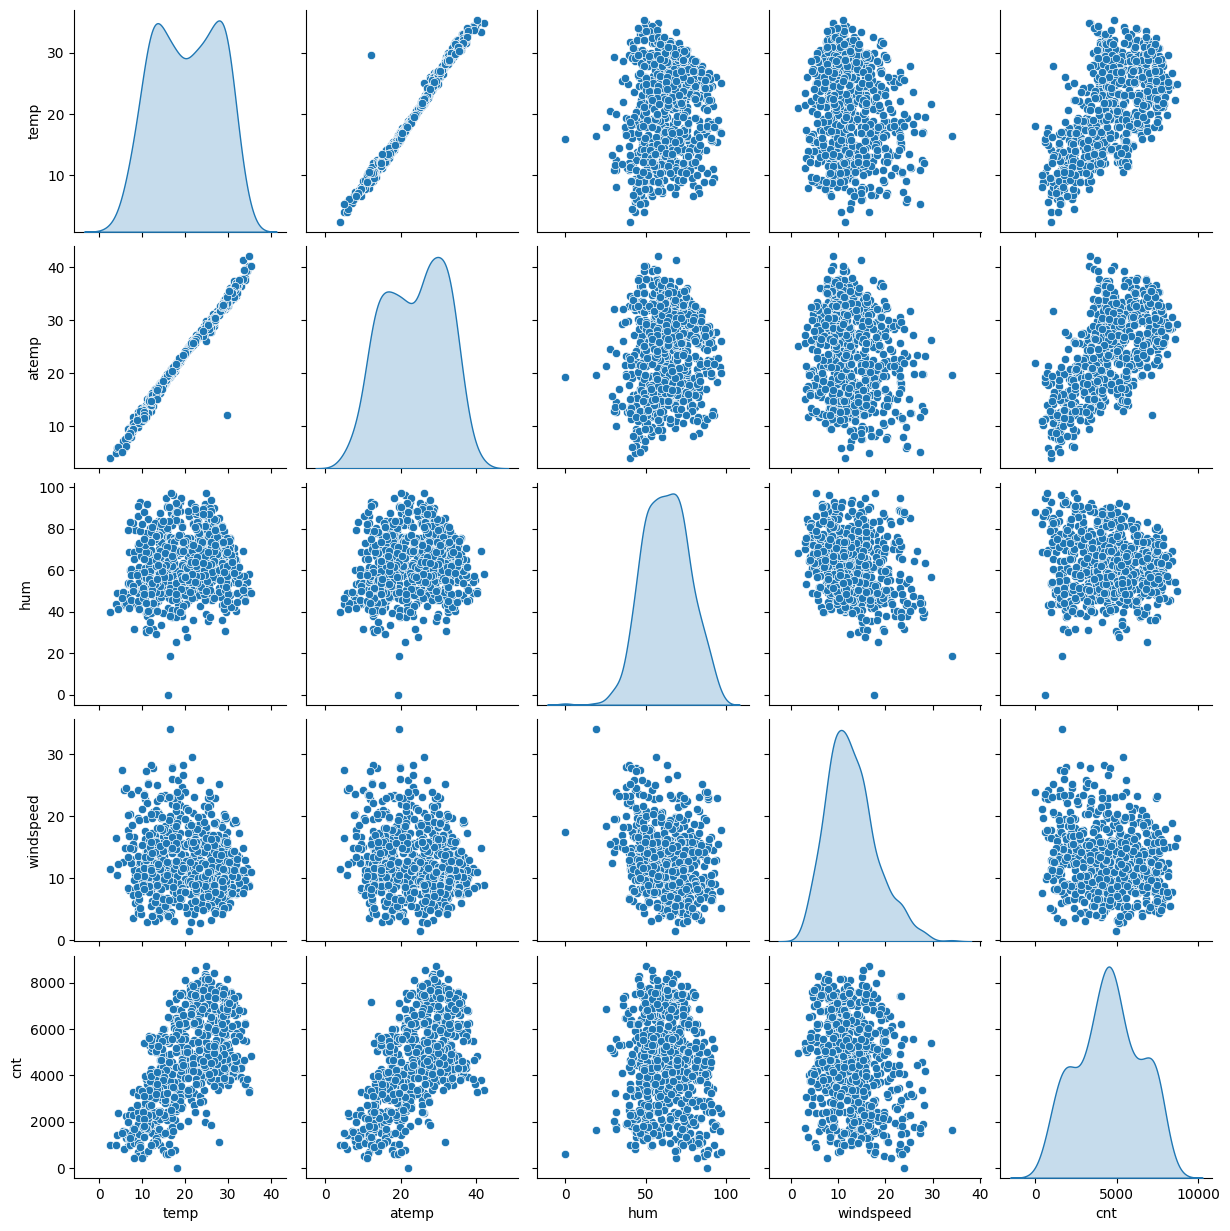

In [146]:
# Pairplot
num_cols = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']
sns.pairplot(df[num_cols], diag_kind='kde')
plt.show()


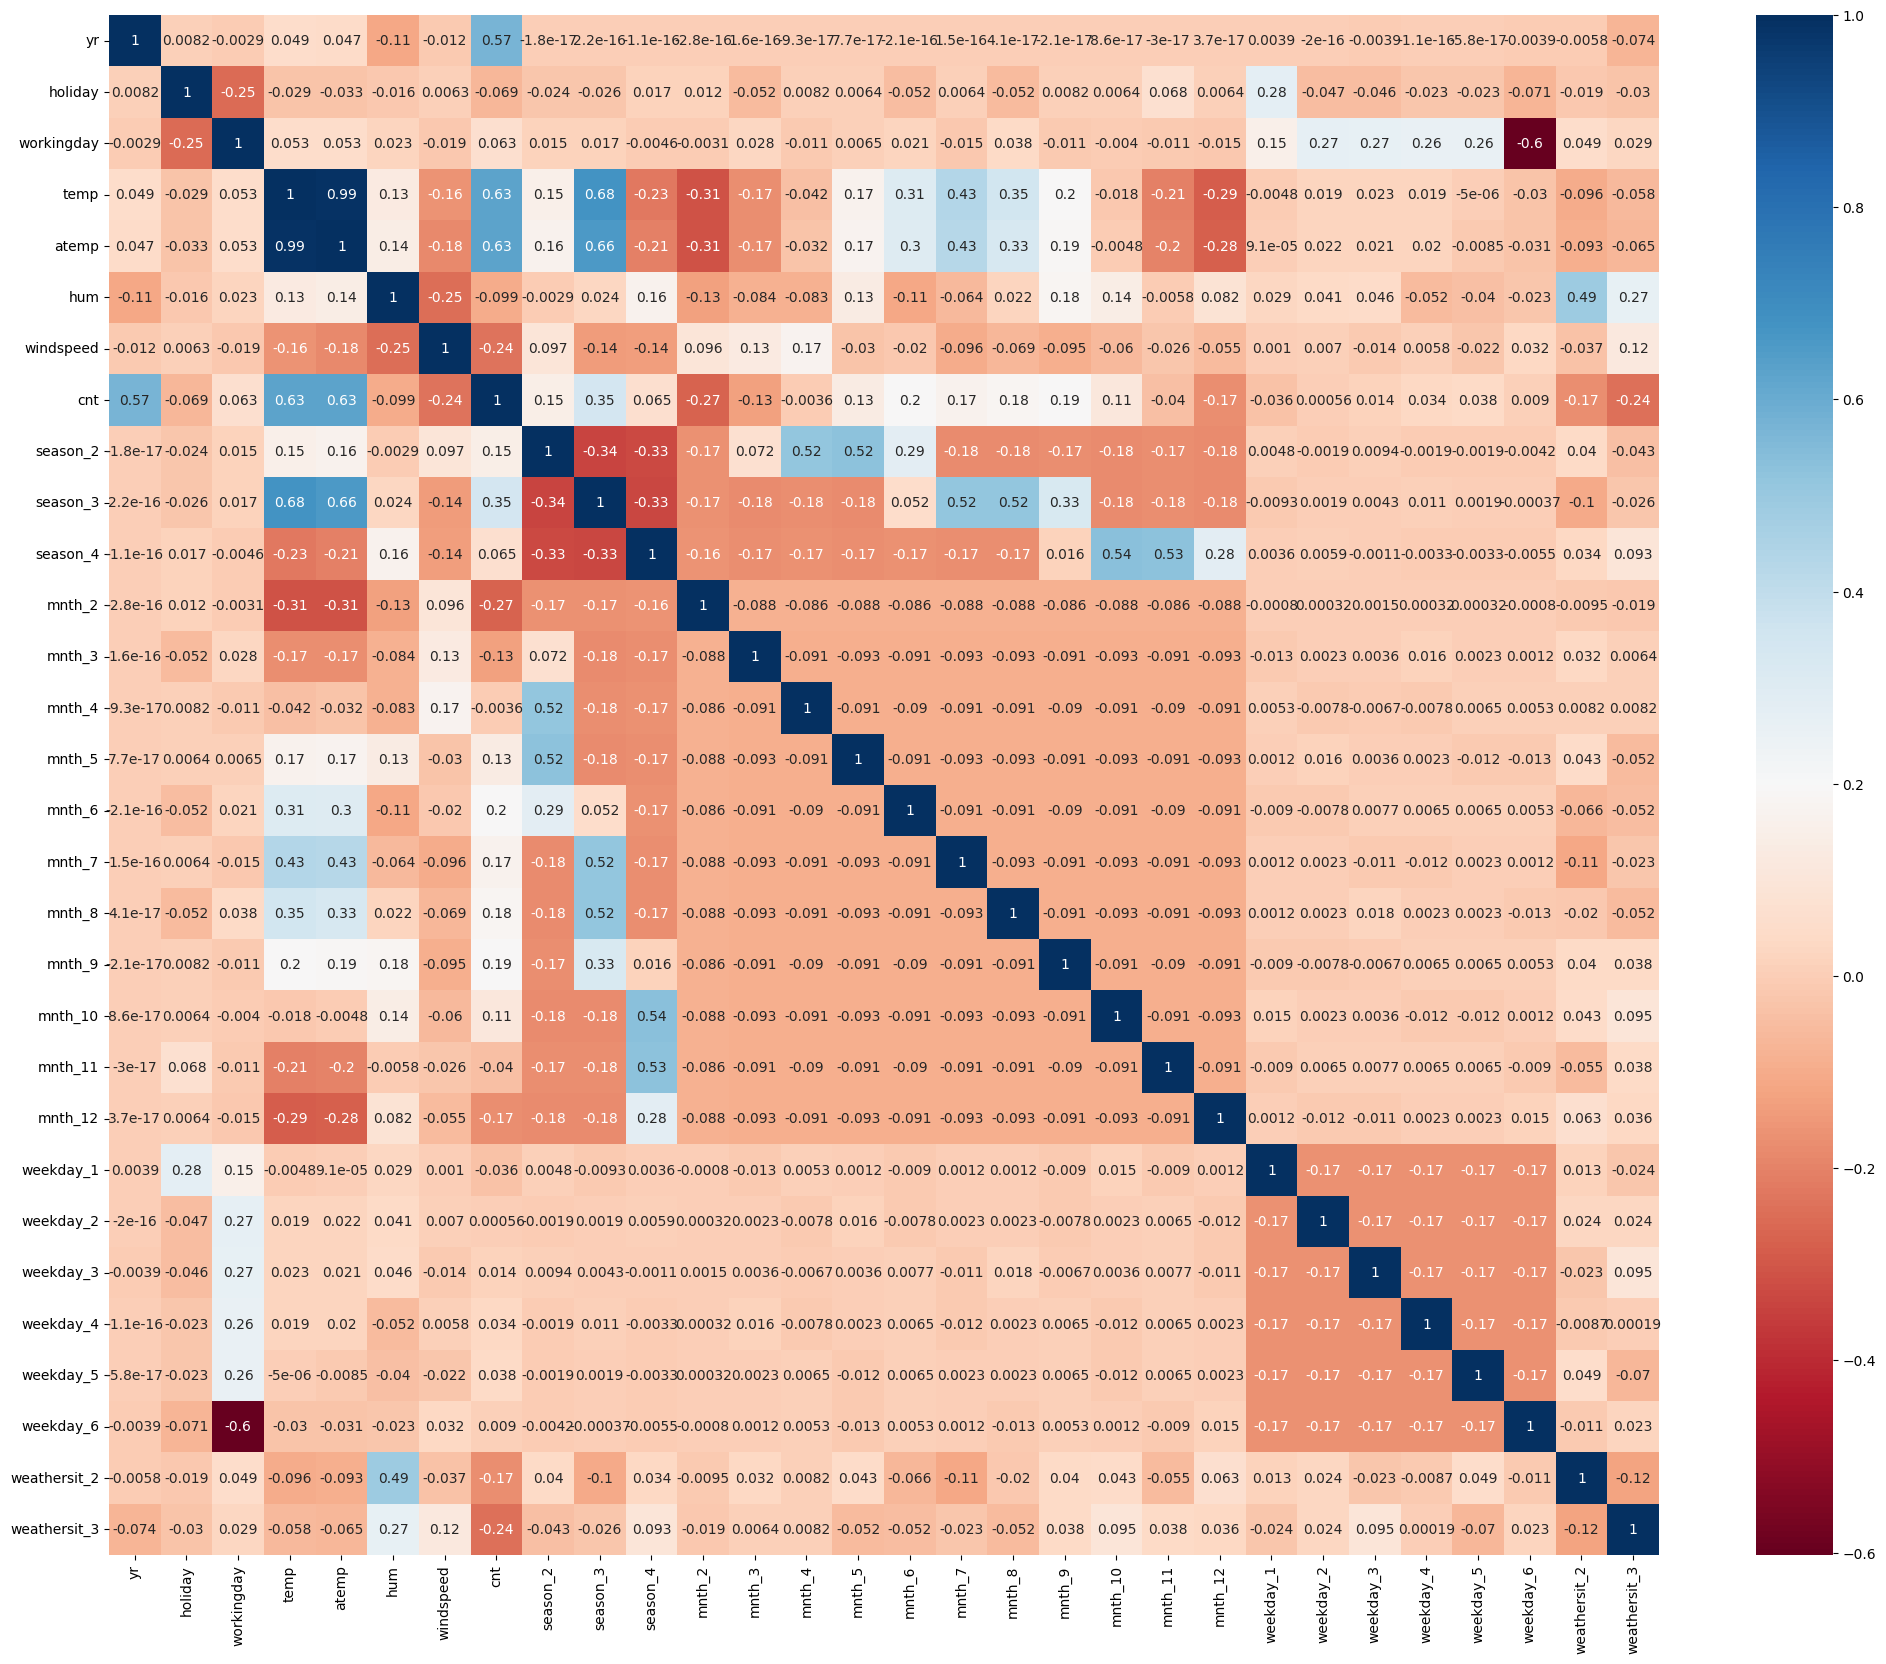

In [147]:
# Correlation heatmap
plt.figure(figsize = (25,20))
sns.heatmap(df.corr(), annot = True, cmap="RdBu")
plt.show()

In [148]:
# Train-Test split
df_train, df_test = train_test_split(
    df, train_size=0.7, random_state=333
)

In [149]:
# Feature scaling
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
num_vars = ['temp','atemp','hum','windspeed','cnt']

df_train[num_vars] = scaler.fit_transform(df_train[num_vars])
df_test[num_vars] = scaler.transform(df_test[num_vars])

In [150]:
# Split X and y
y_train = df_train.pop('cnt')
X_train = df_train
y_test = df_test.pop('cnt')
X_test = df_test

In [151]:
# Feature Selection
from sklearn.feature_selection import RFE

lm = LinearRegression()
rfe = RFE(lm, n_features_to_select=15)
rfe.fit(X_train, y_train)

selected_cols = X_train.columns[rfe.support_]
X_train = X_train[selected_cols]
X_test = X_test[selected_cols]

In [152]:
# Fit Linear Regression Model
rc = LinearRegression()
rc.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [153]:
# Overfitting / Underfitting Check
print("Training R2:", rc.score(X_train, y_train))
print("Testing R2 :", rc.score(X_test, y_test))

Training R2: 0.8417039686452434
Testing R2 : 0.8338899517344207


In [154]:
# Predictions & Error Metrics
from sklearn.metrics import mean_squared_error

y_pred = rc.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MSE :", mse)
print("RMSE:", rmse)


MSE : 0.0079944721626094
RMSE: 0.08941181220962587


In [155]:
# Coefficients & Intercept
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': rc.coef_
})

coef_df.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
2,temp,0.435856
0,yr,0.228351
8,season_4,0.153721
6,season_2,0.129556
10,mnth_9,0.100011
7,season_3,0.079386
3,atemp,0.057604
12,weekday_6,0.055457
11,mnth_10,0.054234
9,mnth_3,0.047424


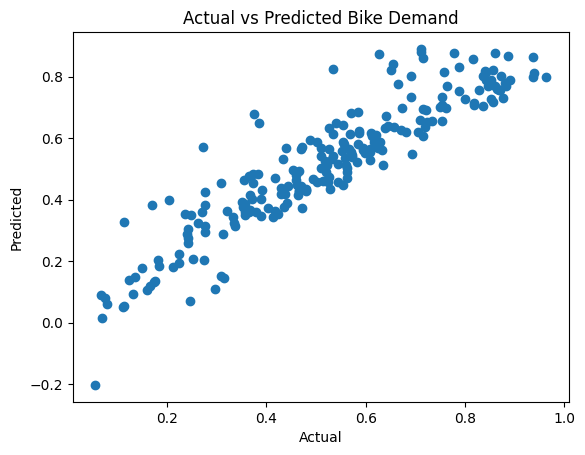

In [156]:
# Actual vs Predicted Plot
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Bike Demand")
plt.show()

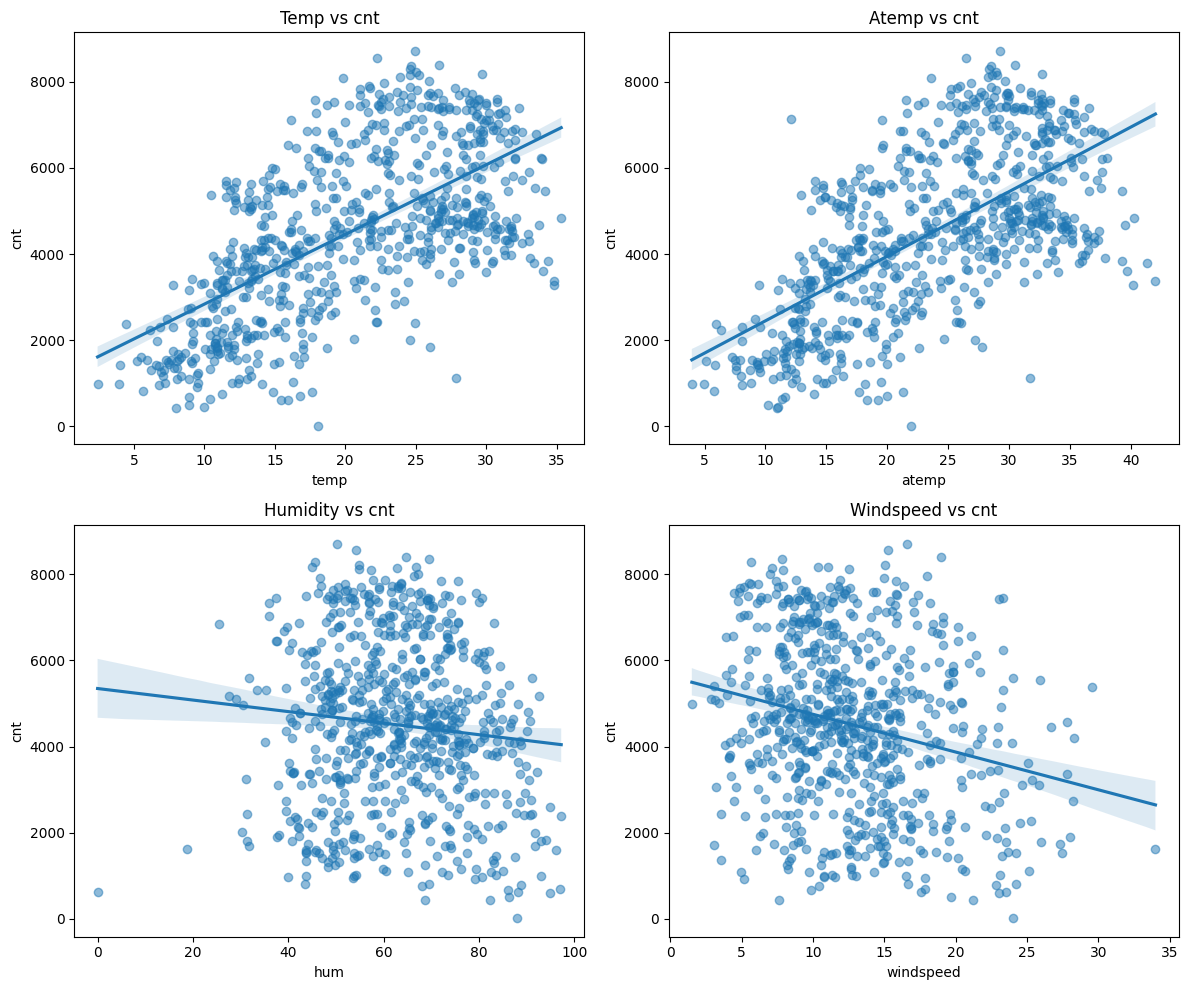

In [ ]:
# Regression line on scatterplots
plt.figure(figsize=(12,10))

plt.subplot(2,2,1)
sns.regplot(x='temp', y='cnt', data=df, scatter_kws={'alpha':0.5})
plt.title('Temp vs cnt')

plt.subplot(2,2,2)
sns.regplot(x='atemp', y='cnt', data=df, scatter_kws={'alpha':0.5})
plt.title('Atemp vs cnt')

plt.subplot(2,2,3)
sns.regplot(x='hum', y='cnt', data=df, scatter_kws={'alpha':0.5})
plt.title('Humidity vs cnt')

plt.subplot(2,2,4)
sns.regplot(x='windspeed', y='cnt', data=df, scatter_kws={'alpha':0.5})
plt.title('Windspeed vs cnt')

plt.tight_layout()
plt.show()
